DATASET SHAPE
(1025, 14)


COLUMN NAMES
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBloodSugar', 'RestingECG', 'MaxHeartRate', 'ExerciseAngina', 'OldPeak', 'STSlope', 'NumMajorVessels', 'Thalassemia', 'HeartDisease']


DATA TYPES
Age                    int64
Sex                    int64
ChestPainType          int64
RestingBP              int64
Cholesterol            int64
FastingBloodSugar      int64
RestingECG             int64
MaxHeartRate           int64
ExerciseAngina         int64
OldPeak              float64
STSlope                int64
NumMajorVessels        int64
Thalassemia            int64
HeartDisease           int64
dtype: object


FIRST 5 ROWS
   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBloodSugar  \
0   52    1              0        125          212                  0   
1   53    1              0        140          203                  1   
2   70    1              0        145          174                  0   
3   61    1        

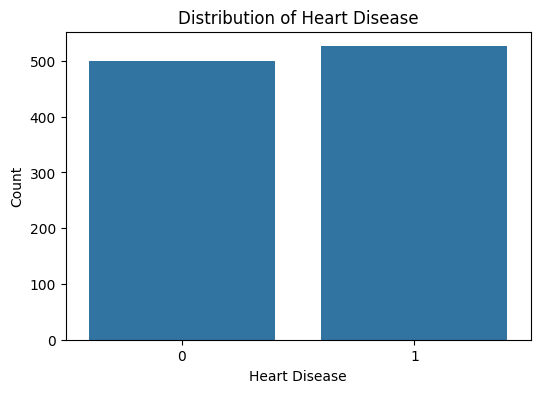

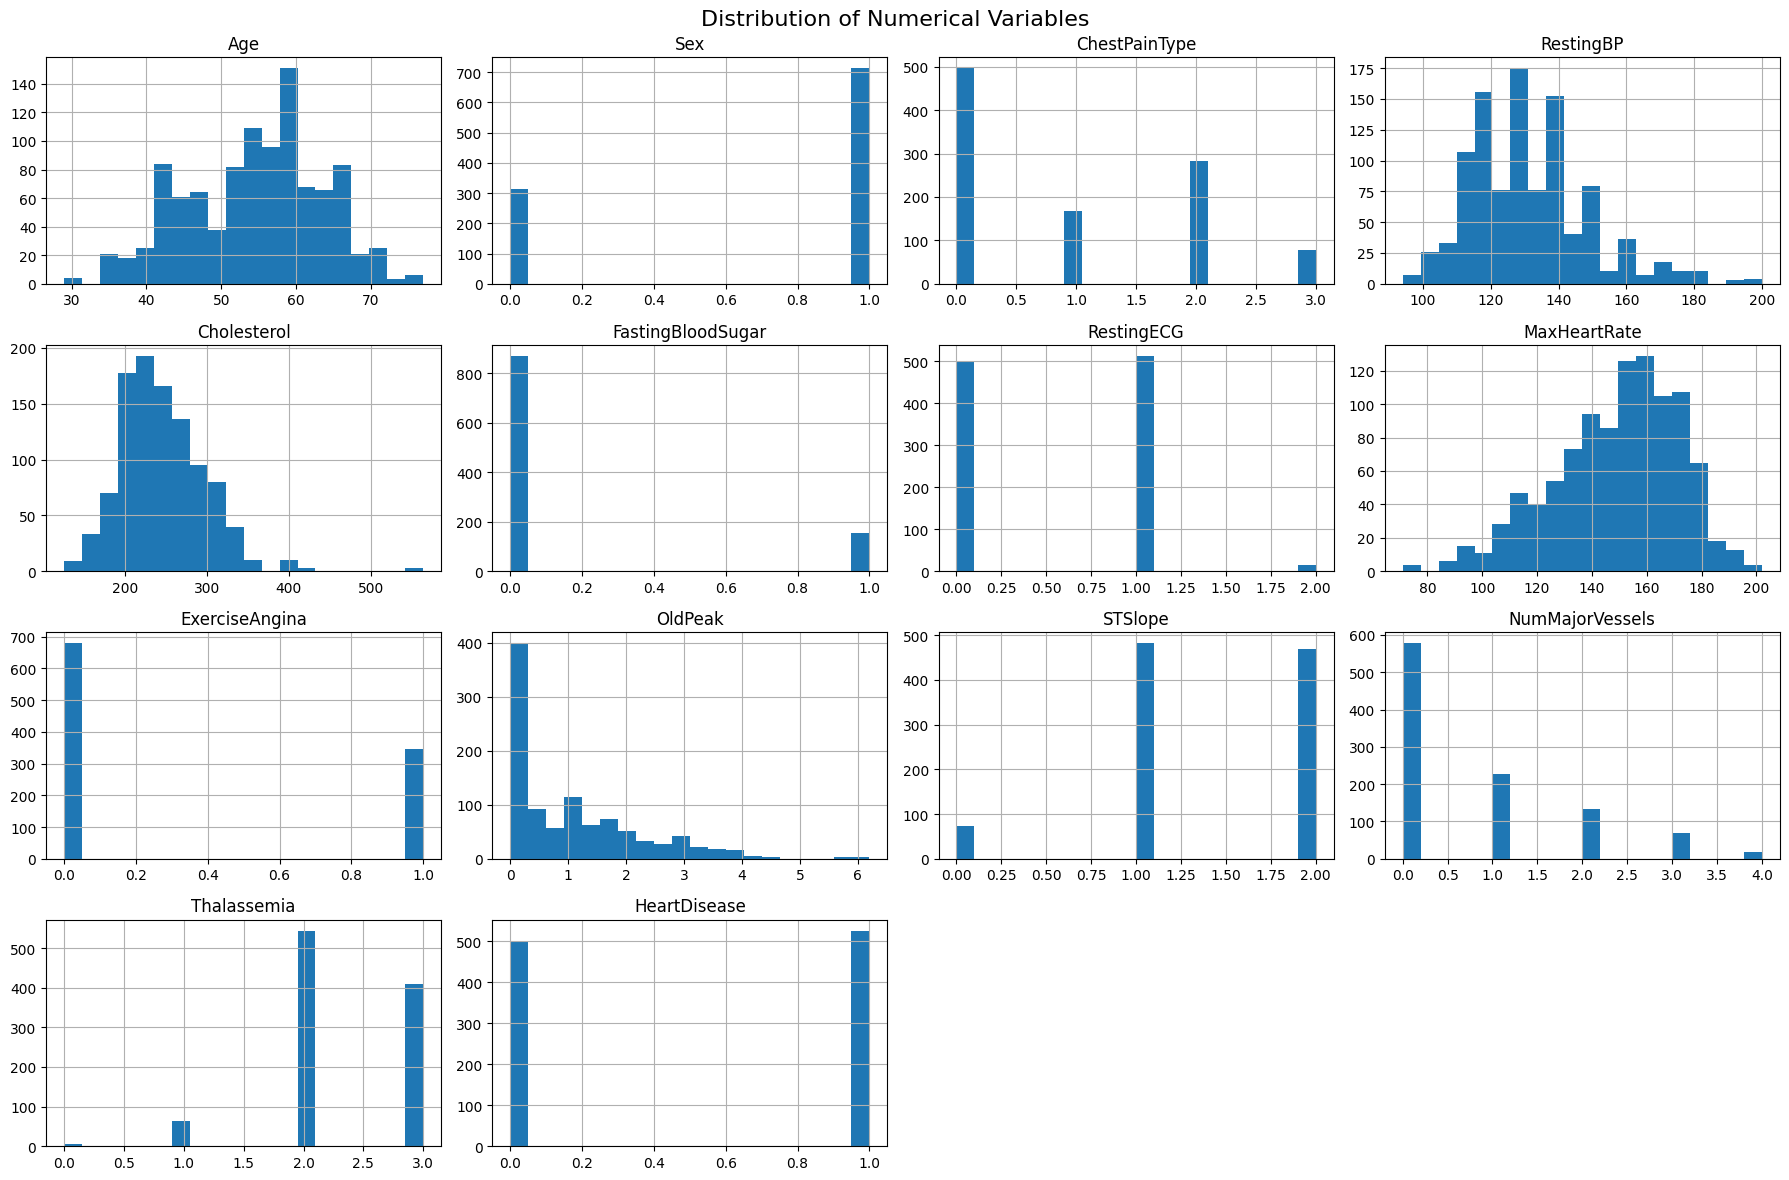

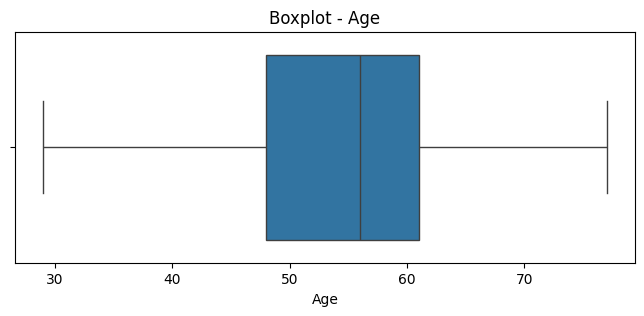

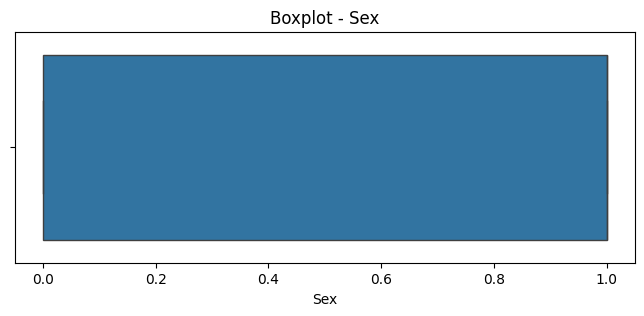

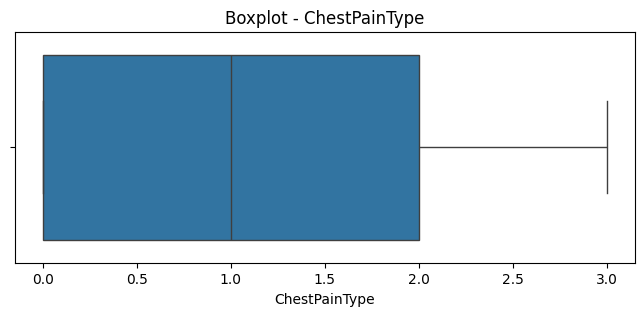

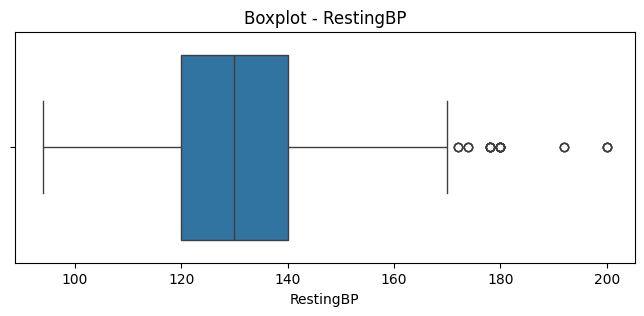

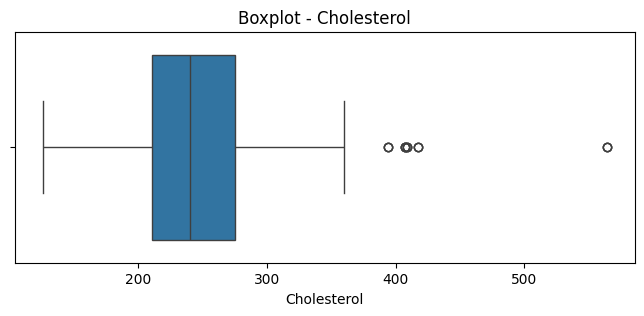

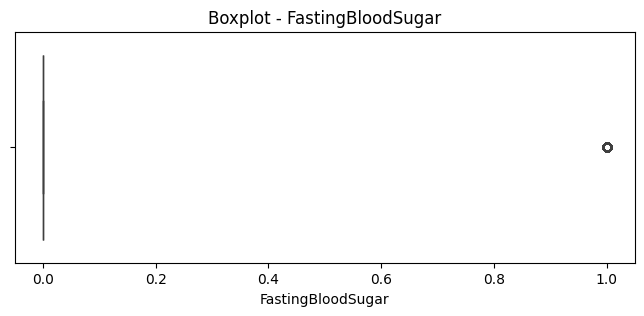

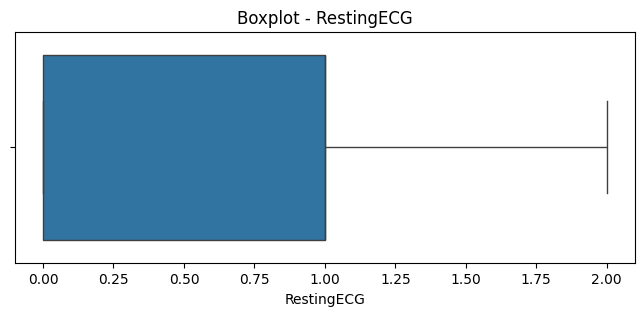

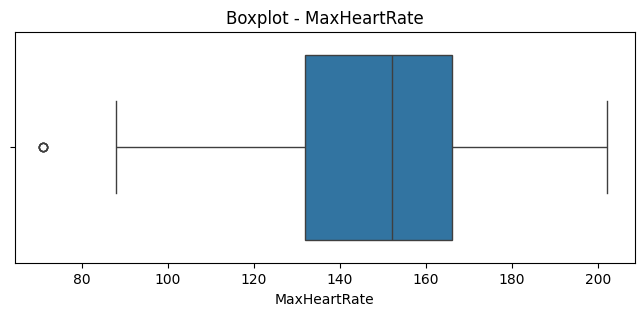

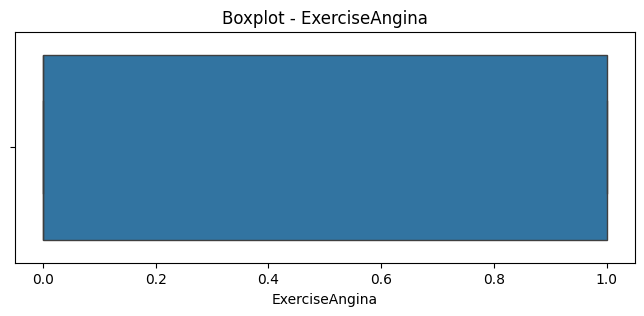

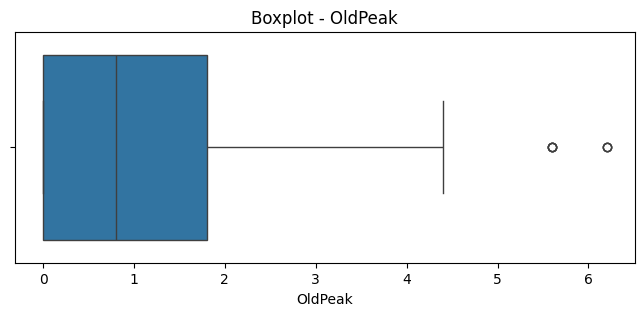

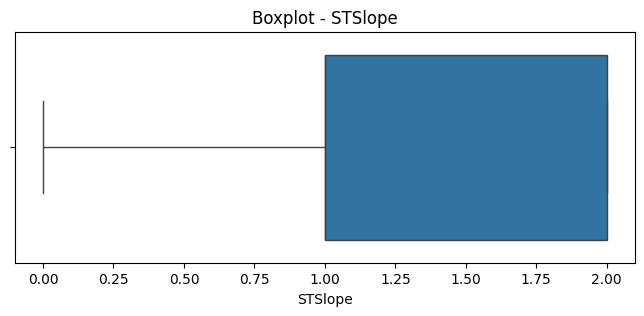

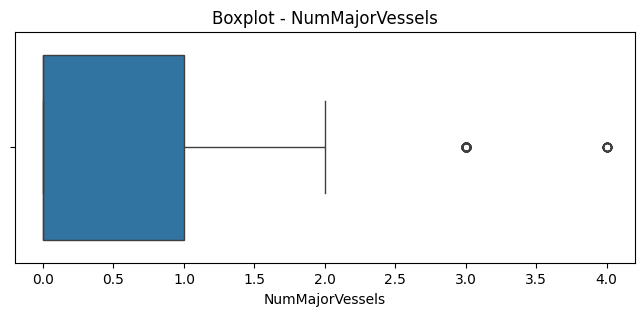

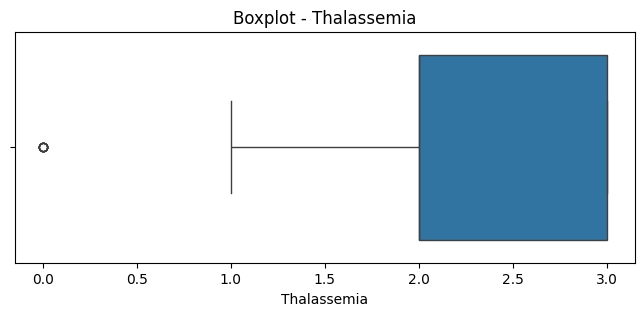

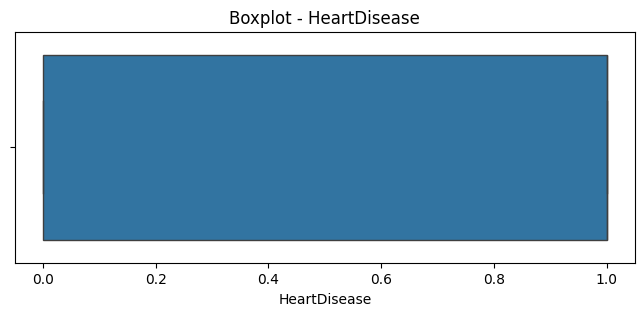

In [1]:
# HEART DISEASE DATASET
# EXPLORATORY DATA ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load dataset


df = pd.read_csv("heart.csv")


# 2. Rename columns


df = df.rename(columns={
    "age": "Age",
    "sex": "Sex",
    "cp": "ChestPainType",
    "trestbps": "RestingBP",
    "chol": "Cholesterol",
    "fbs": "FastingBloodSugar",
    "restecg": "RestingECG",
    "thalach": "MaxHeartRate",
    "exang": "ExerciseAngina",
    "oldpeak": "OldPeak",
    "slope": "STSlope",
    "ca": "NumMajorVessels",
    "thal": "Thalassemia",
    "target": "HeartDisease"
})


# 3. Basic dataset info



print("DATASET SHAPE")
print(df.shape)

print("\n")

print("COLUMN NAMES")
print(df.columns.tolist())

print("\n")


print("DATA TYPES")
print(df.dtypes)

print("\n")


print("FIRST 5 ROWS")
print(df.head())

print("\n")

print("LAST 5 ROWS")
print(df.tail())


# 4. Missing values


print("\n")
print("MISSING VALUES")
print(df.isnull().sum())


# 5. Duplicated rows


print("\n")
print("DUPLICATED ROWS")
print(df.duplicated().sum())


# 6. Descriptive statistics


print("\n")
print("DESCRIPTIVE STATISTICS")
print(df.describe())


# 7. Target variable distribution


print("\n")
print("HEART DISEASE DISTRIBUTION")
print(df["HeartDisease"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="HeartDisease"
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()


# 8. Histograms


df.hist(
    figsize=(18,12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()


# 9. Boxplots


numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numerical_columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot - {col}")

    plt.show()


Dataset shape before removing duplicates:
(1025, 14)

Number of duplicated rows: 723

Duplicated rows removed successfully.

Dataset shape after removing duplicates:
(302, 14)

Missing values after cleaning:
Age                  0
Sex                  0
ChestPainType        0
RestingBP            0
Cholesterol          0
FastingBloodSugar    0
RestingECG           0
MaxHeartRate         0
ExerciseAngina       0
OldPeak              0
STSlope              0
NumMajorVessels      0
Thalassemia          0
HeartDisease         0
dtype: int64

Updated descriptive statistics:
             Age         Sex  ChestPainType   RestingBP  Cholesterol  \
count  302.00000  302.000000     302.000000  302.000000   302.000000   
mean    54.42053    0.682119       0.963576  131.602649   246.500000   
std      9.04797    0.466426       1.032044   17.563394    51.753489   
min     29.00000    0.000000       0.000000   94.000000   126.000000   
25%     48.00000    0.000000       0.000000  120.000000   211.0

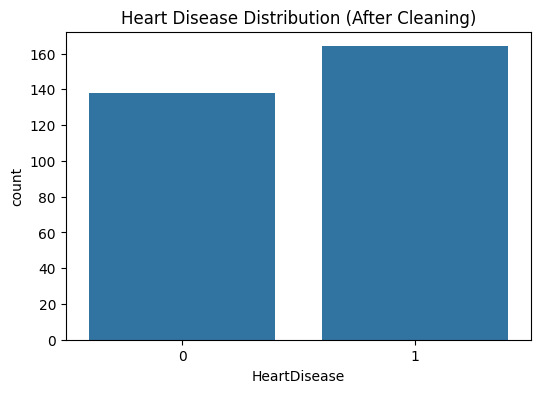

In [2]:
# DATA CLEANING

# 1. Dataset size before cleaning


print("\nDataset shape before removing duplicates:")
print(df.shape)


# 2. Remove duplicated rows


duplicates = df.duplicated().sum()

print(f"\nNumber of duplicated rows: {duplicates}")

df = df.drop_duplicates()

print("\nDuplicated rows removed successfully.")


# 3. Dataset size after cleaning


print("\nDataset shape after removing duplicates:")
print(df.shape)


# 4. Missing values check


print("\nMissing values after cleaning:")

print(df.isnull().sum())


# 5. Check descriptive statistics again


print("\nUpdated descriptive statistics:")

print(df.describe())


# 6. Check target distribution


print("\nTarget distribution after cleaning:")

print(df["HeartDisease"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="HeartDisease"
)

plt.title("Heart Disease Distribution (After Cleaning)")

plt.show()


Correlation Matrix:
                        Age       Sex  ChestPainType  RestingBP  Cholesterol  \
Age                1.000000 -0.094962      -0.063107   0.283121     0.207216   
Sex               -0.094962  1.000000      -0.051740  -0.057647    -0.195571   
ChestPainType     -0.063107 -0.051740       1.000000   0.046486    -0.072682   
RestingBP          0.283121 -0.057647       0.046486   1.000000     0.125256   
Cholesterol        0.207216 -0.195571      -0.072682   0.125256     1.000000   
FastingBloodSugar  0.119492  0.046022       0.096018   0.178125     0.011428   
RestingECG        -0.111590 -0.060351       0.041561  -0.115367    -0.147602   
MaxHeartRate      -0.395235 -0.046439       0.293367  -0.048023    -0.005308   
ExerciseAngina     0.093216  0.143460      -0.392937   0.068526     0.064099   
OldPeak            0.206040  0.098322      -0.146692   0.194600     0.050086   
STSlope           -0.164124 -0.032990       0.116854  -0.122873     0.000417   
NumMajorVessels    

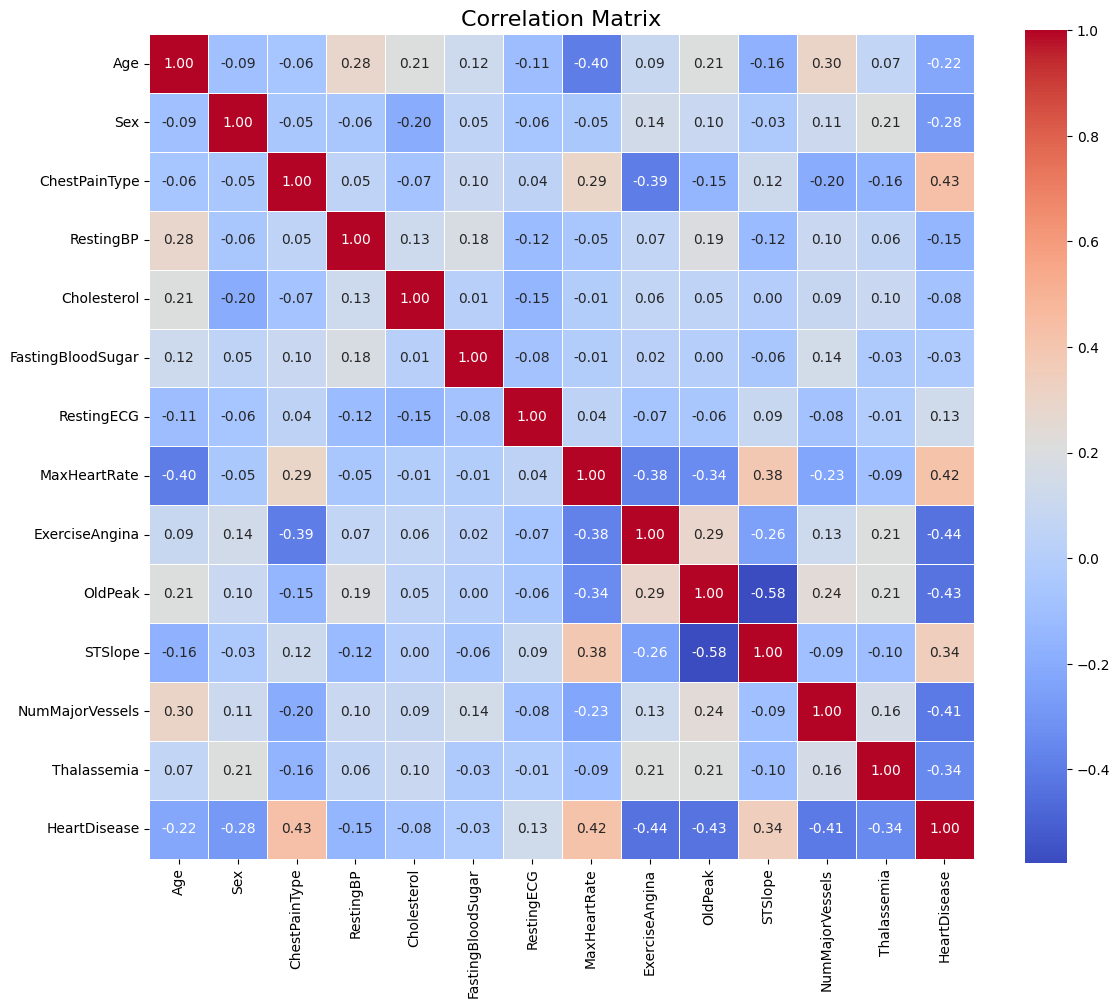


Correlation with Heart Disease:
HeartDisease         1.000000
ChestPainType        0.432080
MaxHeartRate         0.419955
STSlope              0.343940
RestingECG           0.134874
FastingBloodSugar   -0.026826
Cholesterol         -0.081437
RestingBP           -0.146269
Age                 -0.221476
Sex                 -0.283609
Thalassemia         -0.343101
NumMajorVessels     -0.408992
OldPeak             -0.429146
ExerciseAngina      -0.435601
Name: HeartDisease, dtype: float64


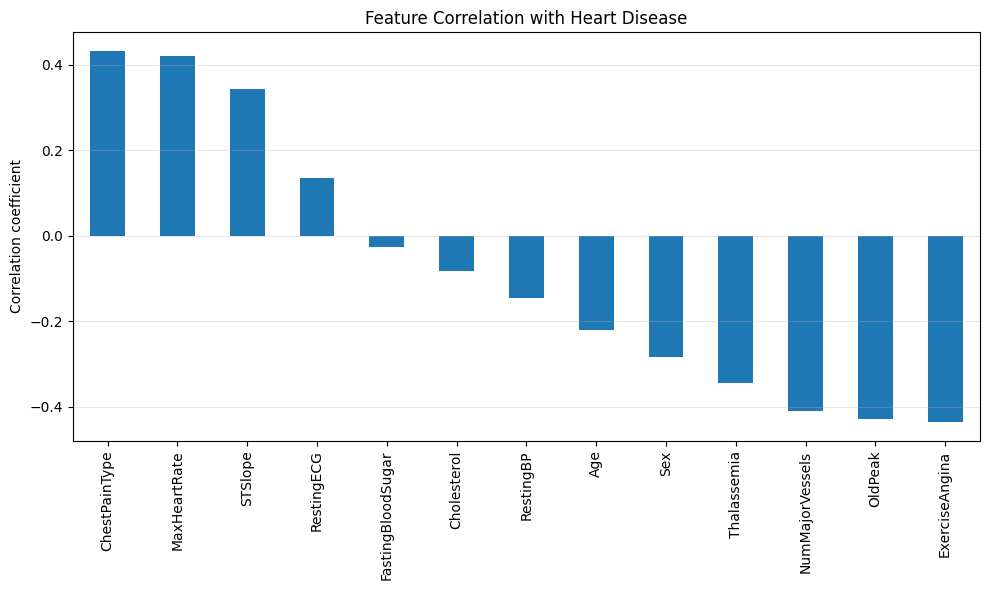


Top Positive Correlations
ChestPainType        0.432080
MaxHeartRate         0.419955
STSlope              0.343940
RestingECG           0.134874
FastingBloodSugar   -0.026826
Name: HeartDisease, dtype: float64

Top Negative Correlations
ExerciseAngina    -0.435601
OldPeak           -0.429146
NumMajorVessels   -0.408992
Thalassemia       -0.343101
Sex               -0.283609
Name: HeartDisease, dtype: float64


In [3]:
# CORRELATION ANALYSIS

# 1. Correlation matrix

correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)


# 2. Heatmap

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()


# 3. Correlation with target variable

target_corr = correlation_matrix["HeartDisease"].sort_values(ascending=False)

print("\nCorrelation with Heart Disease:")
print(target_corr)


# 4. Bar plot

plt.figure(figsize=(10,6))

target_corr.drop("HeartDisease").plot(
    kind="bar"
)

plt.title("Feature Correlation with Heart Disease")
plt.ylabel("Correlation coefficient")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# 5. Strongest positive correlations

print("\nTop Positive Correlations")

print(
    target_corr.drop("HeartDisease")
               .sort_values(ascending=False)
               .head(5)
)


# 6. Strongest negative correlations

print("\nTop Negative Correlations")

print(
    target_corr.sort_values()
               .head(5)
)

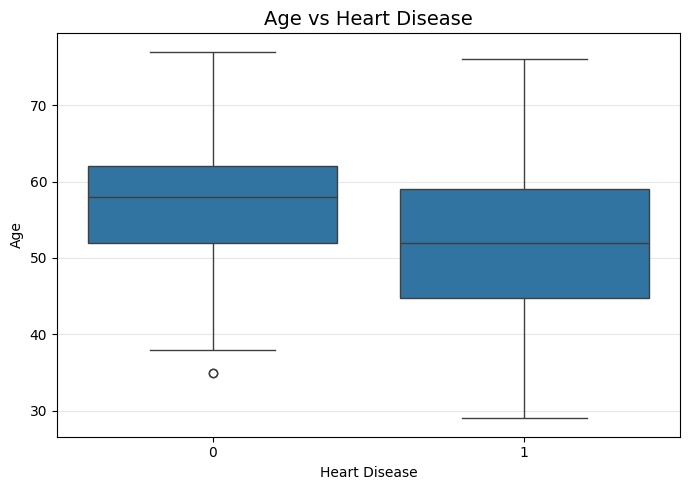

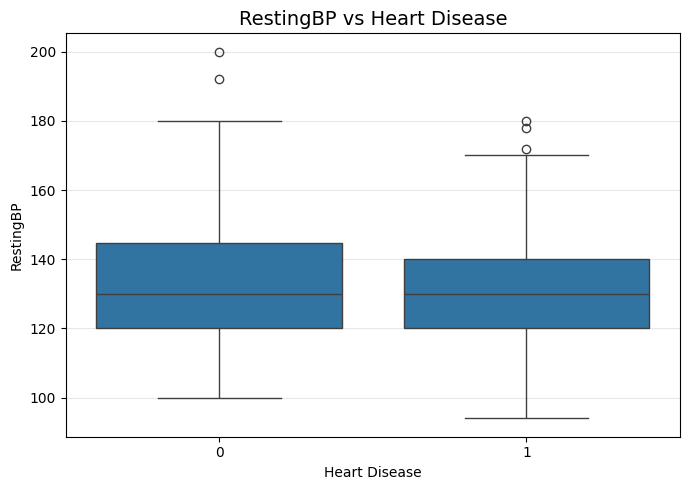

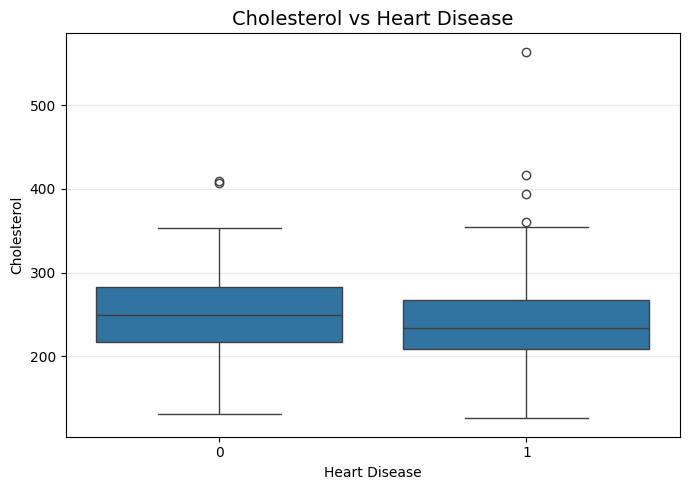

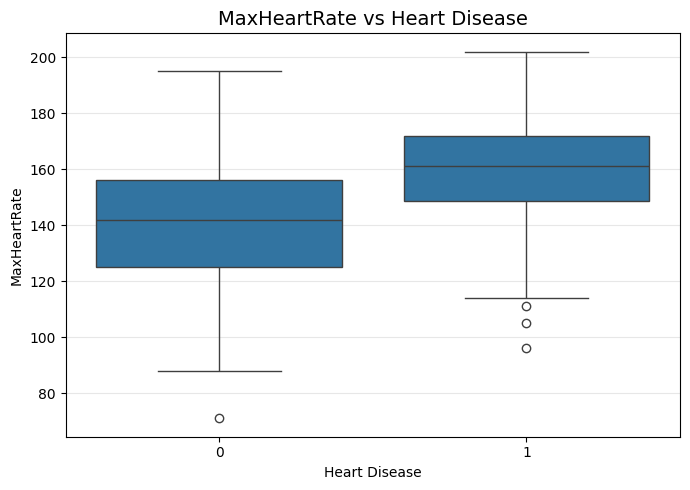

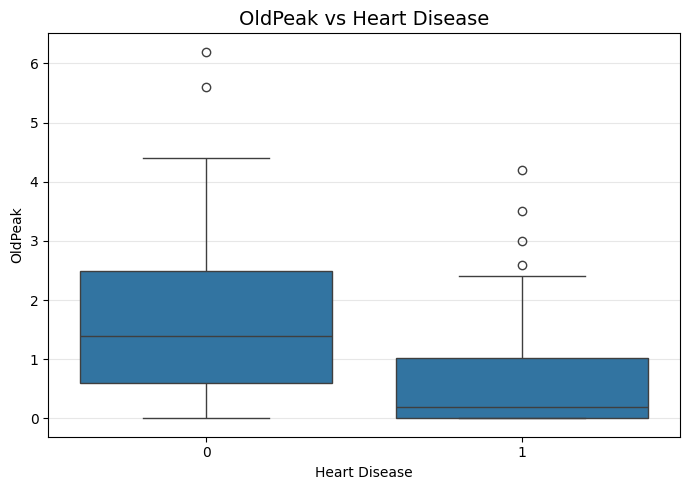

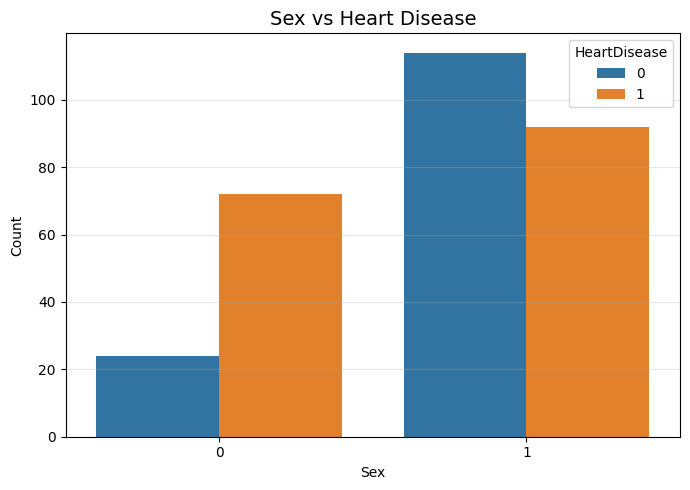

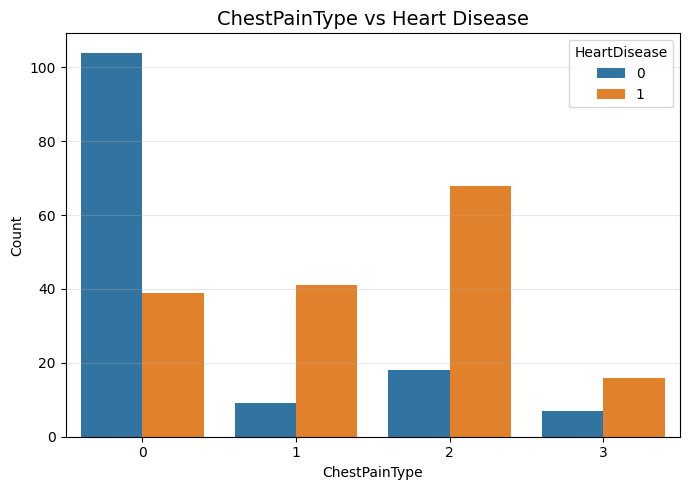

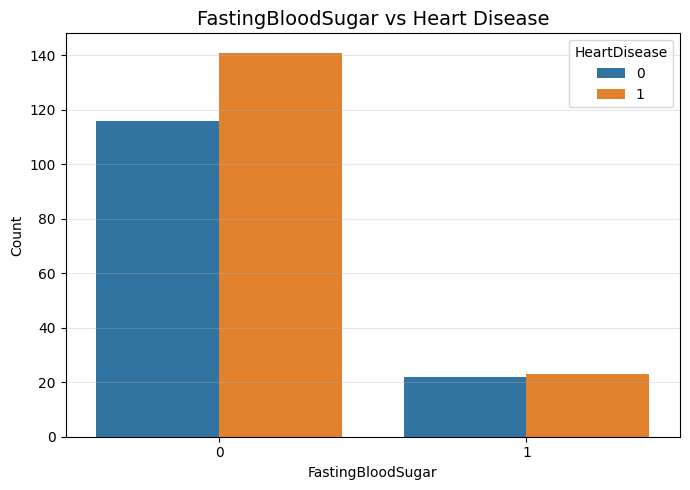

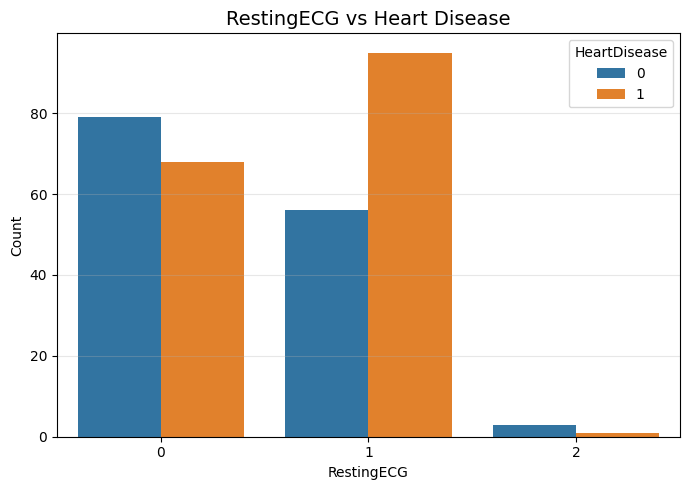

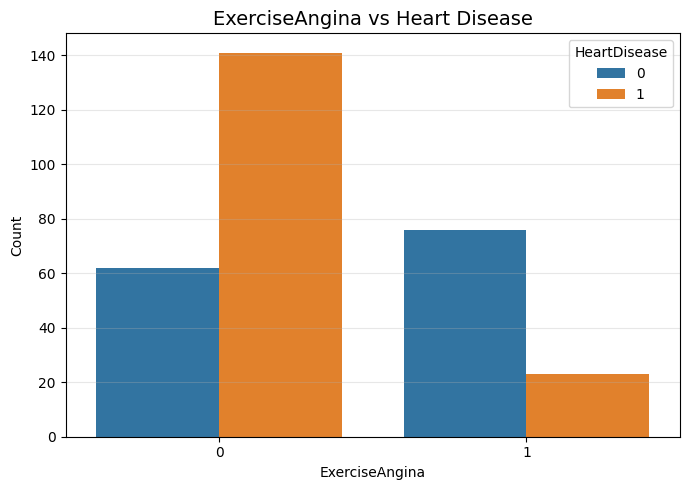

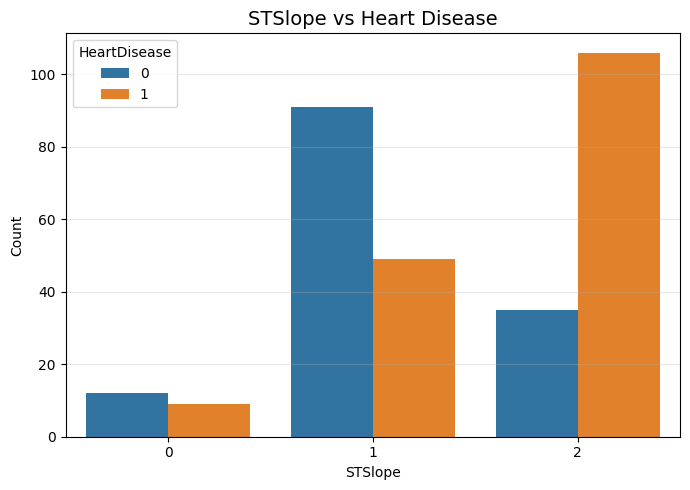

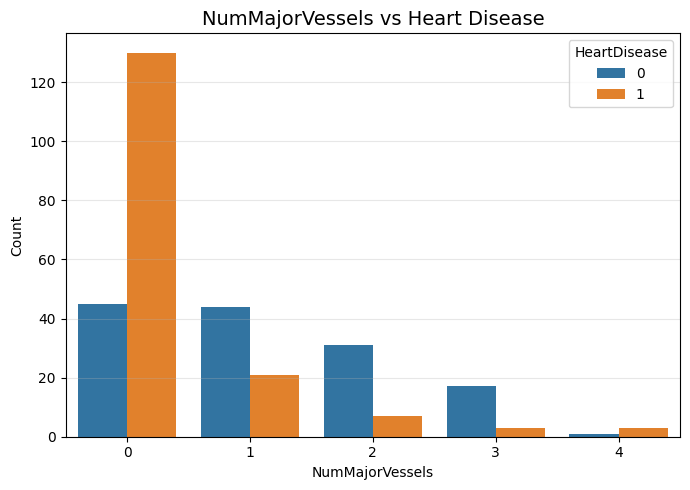

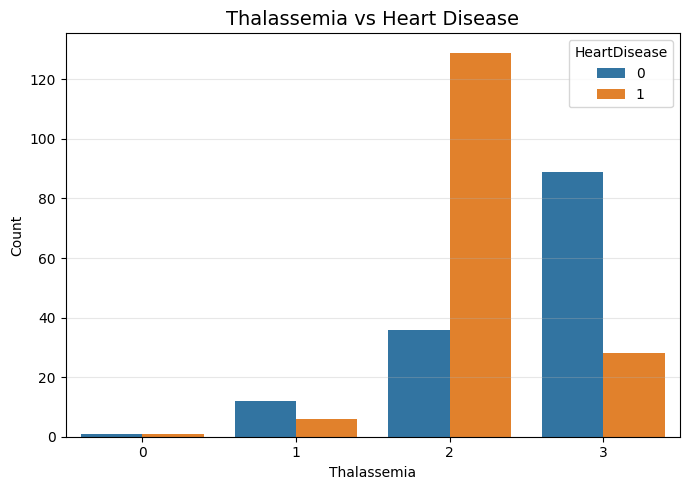



MEAN VALUES GROUPED BY HEART DISEASE
                    Age   RestingBP  Cholesterol  MaxHeartRate   OldPeak
HeartDisease                                                            
0             56.601449  134.398551   251.086957    139.101449  1.585507
1             52.585366  129.250000   242.640244    158.378049  0.586585


SUMMARY STATISTICS BY HEART DISEASE
                Age                                                      \
              count       mean       std   min    25%   50%   75%   max   
HeartDisease                                                              
0             138.0  56.601449  7.962082  35.0  52.00  58.0  62.0  77.0   
1             164.0  52.585366  9.511957  29.0  44.75  52.0  59.0  76.0   

             RestingBP              ... MaxHeartRate        OldPeak            \
                 count        mean  ...          75%    max   count      mean   
HeartDisease                        ...                                         
0           

In [4]:
# FEATURE ANALYSIS

# Numerical Features vs Heart Disease

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHeartRate",
    "OldPeak"
]

for feature in numerical_features:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=feature
    )

    plt.title(f"{feature} vs Heart Disease", fontsize=14)
    plt.xlabel("Heart Disease")
    plt.ylabel(feature)

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# Categorical Features vs Heart Disease

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBloodSugar",
    "RestingECG",
    "ExerciseAngina",
    "STSlope",
    "NumMajorVessels",
    "Thalassemia"
]

for feature in categorical_features:

    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x=feature,
        hue="HeartDisease"
    )

    plt.title(f"{feature} vs Heart Disease", fontsize=14)
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# Mean values grouped by Heart Disease

print("\n")
print("MEAN VALUES GROUPED BY HEART DISEASE")

group_means = df.groupby("HeartDisease")[numerical_features].mean()

print(group_means)


# Summary statistics by Heart Disease

print("\n")
print("SUMMARY STATISTICS BY HEART DISEASE")

summary = df.groupby("HeartDisease")[numerical_features].describe()

print(summary)


Features shape:
(302, 13)

Target shape:
(302,)

Training samples: 241
Testing samples: 61


LOGISTIC REGRESSION

Accuracy:
0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



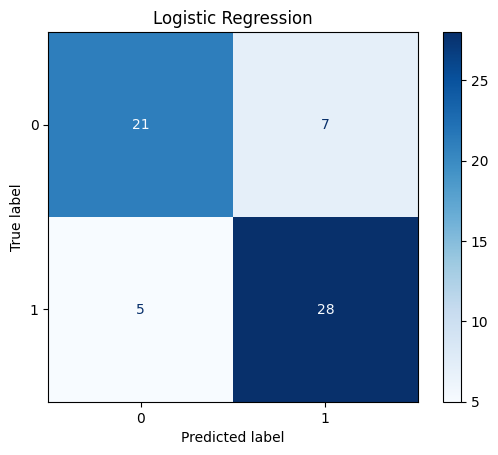



RANDOM FOREST

Accuracy:
0.7869

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



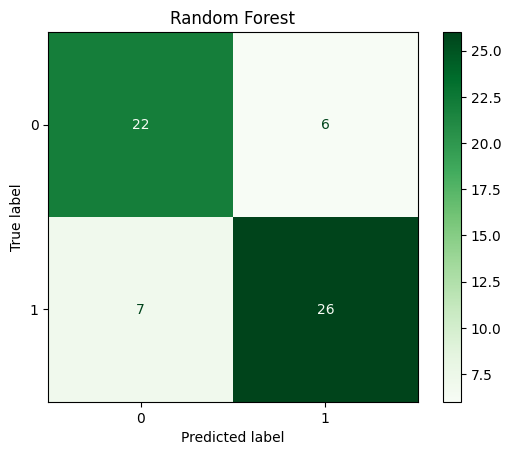



MODEL COMPARISON
Logistic Regression Accuracy : 0.8033
Random Forest Accuracy       : 0.7869

Logistic Regression performed better.


In [5]:
# MACHINE LEARNING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Features and Target

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print("\nFeatures shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression

print("\n")
print("LOGISTIC REGRESSION")

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("\nAccuracy:")
print(round(lr_accuracy,4))

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression")

plt.show()

# Random Forest

print("\n")
print("RANDOM FOREST")

rf_model = RandomForestClassifier(

    n_estimators=300,
    random_state=42

)

rf_model.fit(X_train,y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_predictions)

print("\nAccuracy:")
print(round(rf_accuracy,4))

print("\nClassification Report:")
print(classification_report(y_test,rf_predictions))

cm = confusion_matrix(y_test,rf_predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Greens")

plt.title("Random Forest")

plt.show()

# Model Comparison

print("\n")
print("MODEL COMPARISON")

print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")

print(f"Random Forest Accuracy       : {rf_accuracy:.4f}")

if rf_accuracy > lr_accuracy:
    print("\nRandom Forest performed better.")
else:
    print("\nLogistic Regression performed better.")

In [6]:
# HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV

print("HYPERPARAMETER TUNING")

param_grid = {

    "n_estimators":[100,200,300,500,700],

    "max_depth":[3,5,8,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2"],

    "bootstrap":[True,False]

}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_grid,

    n_iter=30,

    cv=5,

    scoring="roc_auc",

    random_state=42,

    n_jobs=-1,

    verbose=1

)

random_search.fit(X_train,y_train)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(random_search.best_score_,4))

HYPERPARAMETER TUNING
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 3, 'bootstrap': True}

Best Cross Validation Accuracy:
0.9131


BEST MODEL EVALUATION

Test Accuracy:
0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



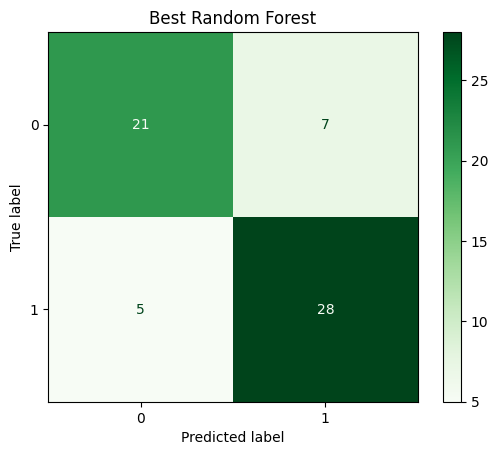

In [7]:
# BEST MODEL EVALUATION

print("BEST MODEL EVALUATION")

best_model = random_search.best_estimator_

predictions = best_model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)

print("\nTest Accuracy:")

print(round(accuracy,4))

print("\nClassification Report:")

print(classification_report(y_test,predictions))

cm = confusion_matrix(y_test,predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Greens")

plt.title("Best Random Forest")

plt.show()

In [8]:
# CROSS VALIDATION

from sklearn.model_selection import cross_val_score

print("5-FOLD CROSS VALIDATION")

scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print("\nFold Accuracies:")

print(scores)

print("\nMean Accuracy:")

print(scores.mean())

print("\nStandard Deviation:")

print(scores.std())

5-FOLD CROSS VALIDATION

Fold Accuracies:
[0.86885246 0.86885246 0.91666667 0.8        0.75      ]

Mean Accuracy:
0.8408743169398907

Standard Deviation:
0.05871777313523767


ROC CURVE


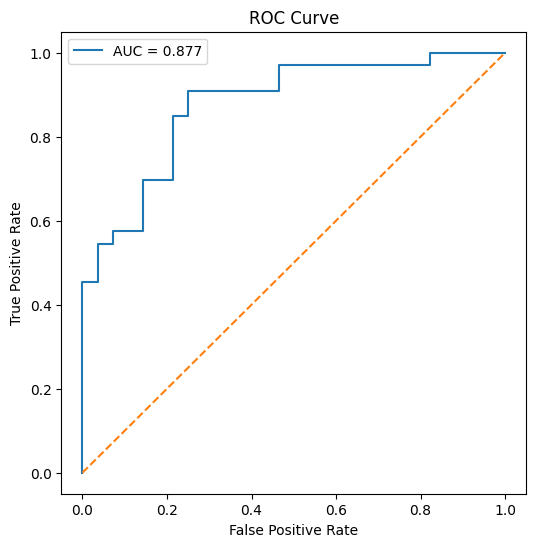

AUC Score: 0.8766


In [9]:
# ROC CURVE

from sklearn.metrics import roc_curve, auc

print("ROC CURVE")

probabilities = best_model.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(y_test,probabilities)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:",round(roc_auc,4))

FEATURE IMPORTANCE
              Feature  Importance
2       ChestPainType    0.226670
12        Thalassemia    0.146572
11    NumMajorVessels    0.137289
7        MaxHeartRate    0.125597
8      ExerciseAngina    0.120719
9             OldPeak    0.090854
0                 Age    0.035666
1                 Sex    0.033221
10            STSlope    0.033013
4         Cholesterol    0.024064
3           RestingBP    0.013815
6          RestingECG    0.010014
5   FastingBloodSugar    0.002505


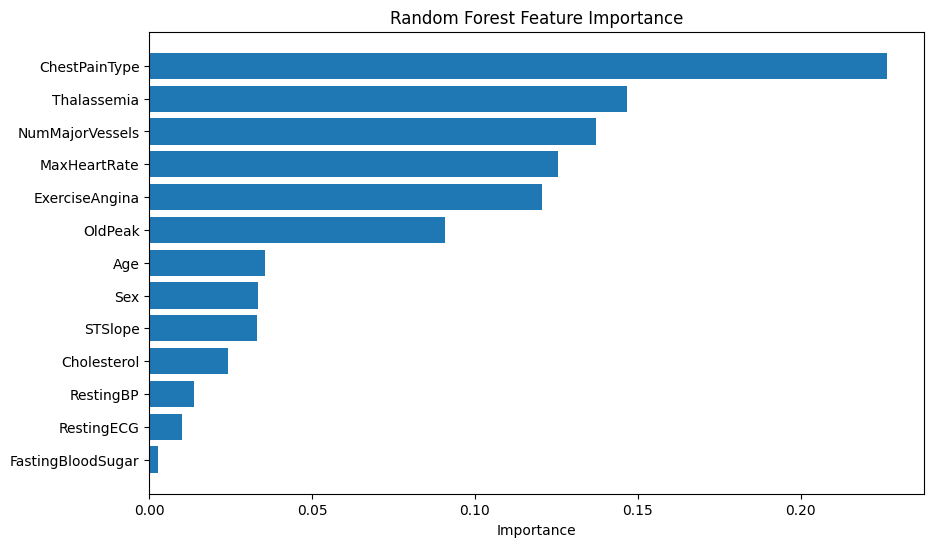

In [10]:
# FEATURE IMPORTANCE

print("FEATURE IMPORTANCE")

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print(importance)

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.show()

In [11]:
# SAVE MODEL

import joblib

joblib.dump(best_model,"heart_disease_model.pkl")

print("Model successfully saved.")

Model successfully saved.
